In [17]:
import importlib
import miaw
importlib.reload(miaw)
from miaw import FFNN
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import OneHotEncoder
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils import check_random_state
from sklearn.metrics import accuracy_score


In [18]:
# Extract the dataset
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)

random_state = check_random_state(0)
permutation = random_state.permutation(X.shape[0])
X = X[permutation]
y = y[permutation]
X = X.reshape((X.shape[0], -1))

encoder = OneHotEncoder(sparse_output=False, categories='auto')
y_encoded = encoder.fit_transform(y.reshape(-1, 1))
# train-test split
X_train, X_val, y_train, y_val = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

In [19]:
print(X_train.shape)
print(X_val.shape)

(56000, 784)
(14000, 784)


# Analysis of Parameters

### 1. Learning Rate

Epoch 1/10: 100%|█████████████████████████████████████████| 56000/56000 [00:00<00:00, 109992.02it/s]


Epoch 1 Completed - Train Loss: 1.5148 - Val Loss: 0.7339


Epoch 2/10: 100%|█████████████████████████████████████████| 56000/56000 [00:00<00:00, 121994.76it/s]


Epoch 2 Completed - Train Loss: 0.6045 - Val Loss: 0.5556


Epoch 3/10: 100%|█████████████████████████████████████████| 56000/56000 [00:00<00:00, 116254.89it/s]


...

Epoch 8 Completed - Train Loss: 0.2612 - Val Loss: 0.3208


Epoch 9/10: 100%|█████████████████████████████████████████| 56000/56000 [00:00<00:00, 123081.78it/s]


Epoch 9 Completed - Train Loss: 0.2452 - Val Loss: 0.3167


Epoch 10/10: 100%|████████████████████████████████████████| 56000/56000 [00:00<00:00, 120601.54it/s]


Epoch 10 Completed - Train Loss: 0.2313 - Val Loss: 0.2984
Accuracy: 92.11%


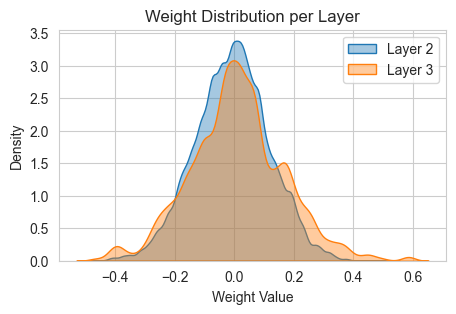

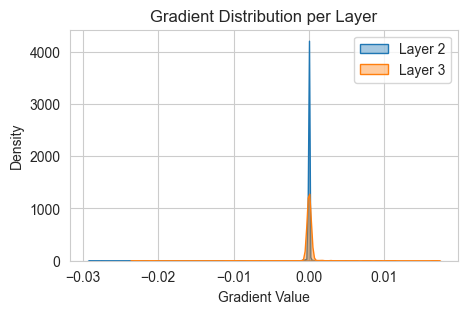

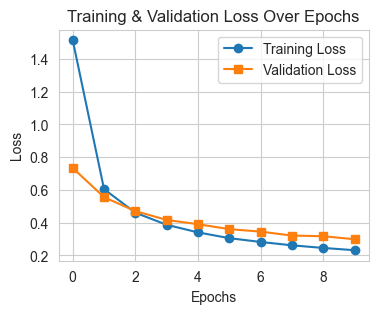

Accuracy: 92.11%


In [20]:
miawlenteraModel = FFNN([784,128,64,10], ['relu','relu','softmax'],loss_function='cce', use_rmsnorm=False, reg_type="l2", weight_init='he')

history = miawlenteraModel.fit(X_train, y_train, X_val, y_val, epochs=10, batch_size=64, lr=0.05, verbose=1)

miaw_pred = miawlenteraModel.predict(X_val)
y_val_labels = np.argmax(y_val, axis=1)
# miaw_pred_labels = np.argmax(miaw_pred, axis=1)

accuracy = accuracy_score(y_val_labels, miaw_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

miawlenteraModel.plot_distribution([1,2], plot_type="weight")
miawlenteraModel.plot_distribution([1,2], plot_type="gradient")
miawlenteraModel.plot_loss_history(history)

miawlenteraModel.save('./models/depth1.json')

testload = FFNN.load('./models/depth1.json')

miaw_p = testload.predict(X_val)
y_val_labels = np.argmax(y_val,axis=1)
miaw_pred_labels = np.argmax(miaw_p, axis=1)

accuracy_new = accuracy_score(y_val_labels,miaw_pred_labels)
print(f"Accuracy: {accuracy_new * 100:.2f}%")


Epoch 1/10: 100%|█████████████████████████████████████████| 56000/56000 [00:00<00:00, 113691.09it/s]


Epoch 1 Completed - Train Loss: 4.0394 - Val Loss: 2.1830


Epoch 2/10: 100%|█████████████████████████████████████████| 56000/56000 [00:00<00:00, 119545.23it/s]


Epoch 2 Completed - Train Loss: 1.6938 - Val Loss: 1.6301


Epoch 3/10: 100%|██████████████████████████████████████████| 56000/56000 [00:00<00:00, 98417.95it/s]


...

Epoch 8 Completed - Train Loss: 0.5392 - Val Loss: 0.7922


Epoch 9/10: 100%|█████████████████████████████████████████| 56000/56000 [00:00<00:00, 113643.02it/s]


Epoch 9 Completed - Train Loss: 0.4849 - Val Loss: 0.7531


Epoch 10/10: 100%|████████████████████████████████████████| 56000/56000 [00:00<00:00, 107898.51it/s]


Epoch 10 Completed - Train Loss: 0.4406 - Val Loss: 0.7029
Accuracy: 89.92%


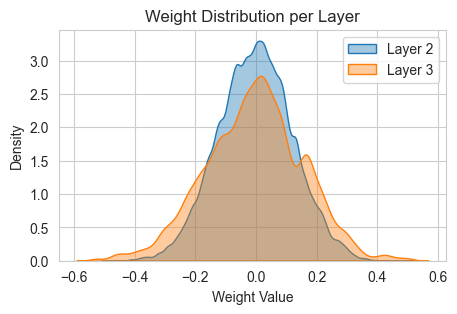

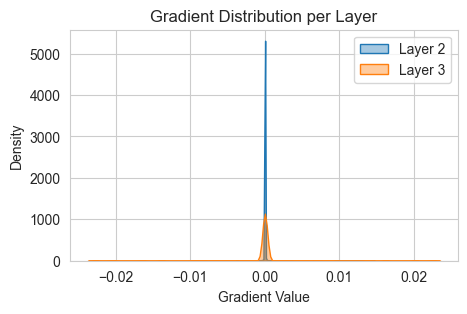

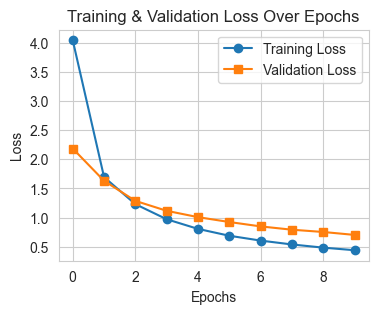

Accuracy: 89.92%


In [21]:
miawlenteraModel = FFNN([784,128,64,10], ['relu','relu','softmax'],loss_function='cce', use_rmsnorm=False, reg_type="l2", weight_init='he')

history = miawlenteraModel.fit(X_train, y_train, X_val, y_val, epochs=10, batch_size=64, lr=0.01, verbose=1)

miaw_pred = miawlenteraModel.predict(X_val)
y_val_labels = np.argmax(y_val, axis=1)
# miaw_pred_labels = np.argmax(miaw_pred, axis=1)

accuracy = accuracy_score(y_val_labels, miaw_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

miawlenteraModel.plot_distribution([1,2], plot_type="weight")
miawlenteraModel.plot_distribution([1,2], plot_type="gradient")
miawlenteraModel.plot_loss_history(history)

miawlenteraModel.save('./models/depth2.json')

testload = FFNN.load('./models/depth2.json')

miaw_p = testload.predict(X_val)
y_val_labels = np.argmax(y_val,axis=1)
miaw_pred_labels = np.argmax(miaw_p, axis=1)

accuracy_new = accuracy_score(y_val_labels,miaw_pred_labels)
print(f"Accuracy: {accuracy_new * 100:.2f}%")


Epoch 1/10: 100%|█████████████████████████████████████████| 56000/56000 [00:00<00:00, 107194.93it/s]


Epoch 1 Completed - Train Loss: 9.5934 - Val Loss: 5.9658


Epoch 2/10: 100%|█████████████████████████████████████████| 56000/56000 [00:00<00:00, 114244.41it/s]


Epoch 2 Completed - Train Loss: 5.0028 - Val Loss: 4.4471


Epoch 3/10: 100%|█████████████████████████████████████████| 56000/56000 [00:00<00:00, 128094.59it/s]


...

Epoch 8 Completed - Train Loss: 2.3399 - Val Loss: 2.5632


Epoch 9/10: 100%|█████████████████████████████████████████| 56000/56000 [00:00<00:00, 106961.45it/s]


Epoch 9 Completed - Train Loss: 2.1941 - Val Loss: 2.4425


Epoch 10/10: 100%|████████████████████████████████████████| 56000/56000 [00:00<00:00, 109629.57it/s]


Epoch 10 Completed - Train Loss: 2.0727 - Val Loss: 2.3466
Accuracy: 84.12%


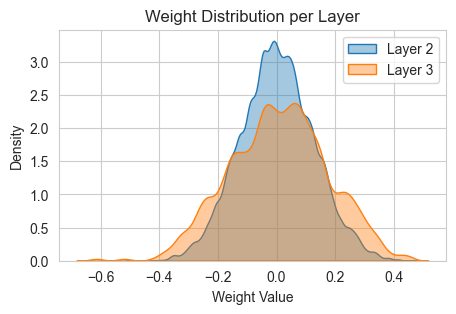

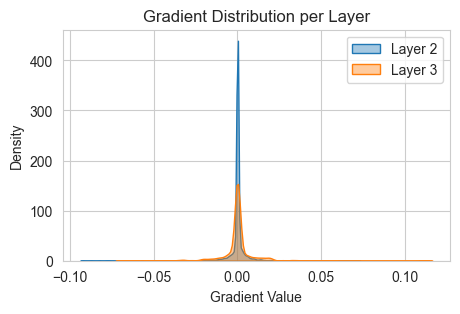

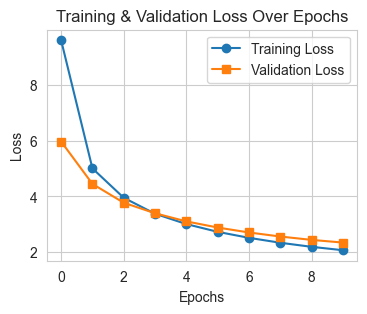

Accuracy: 84.12%


In [22]:
miawlenteraModel = FFNN([784,128,64,10], ['relu','relu','softmax'],loss_function='cce', use_rmsnorm=False, reg_type="l2", weight_init='he')

history = miawlenteraModel.fit(X_train, y_train, X_val, y_val, epochs=10, batch_size=64, lr=0.001, verbose=1)

miaw_pred = miawlenteraModel.predict(X_val)
y_val_labels = np.argmax(y_val, axis=1)
# miaw_pred_labels = np.argmax(miaw_pred, axis=1)

accuracy = accuracy_score(y_val_labels, miaw_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

miawlenteraModel.plot_distribution([1,2], plot_type="weight")
miawlenteraModel.plot_distribution([1,2], plot_type="gradient")
miawlenteraModel.plot_loss_history(history)

miawlenteraModel.save('./models/depth3.json')

testload = FFNN.load('./models/depth3.json')

miaw_p = testload.predict(X_val)
y_val_labels = np.argmax(y_val,axis=1)
miaw_pred_labels = np.argmax(miaw_p, axis=1)

accuracy_new = accuracy_score(y_val_labels,miaw_pred_labels)
print(f"Accuracy: {accuracy_new * 100:.2f}%")
